# ZaloPay – Part II · Câu 2 & 3
## Câu 2: Segmentation (RFM) + Retention Rate
## Câu 3: Churn Rate

---

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#F8F8F6',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'grid.linestyle'   : '--',
    'font.family'      : 'DejaVu Sans',
})

BLUE   = '#378ADD'; TEAL   = '#1D9E75'; AMBER  = '#EF9F27'
CORAL  = '#D85A30'; PURPLE = '#7F77DD'; GRAY   = '#B4B2A9'
GREEN  = '#639922'; PINK   = '#D4537E'

SEG_COLORS = {
    'Champions'    : TEAL,
    'Loyal'        : BLUE,
    'New Users'    : GREEN,
    'Promising'    : PURPLE,
    'At Risk'      : AMBER,
    'Cant Lose Them': CORAL,
    'Lost'         : GRAY,
}

In [2]:
# ── Load data ──────────────────────────────────────────────────────────────────
BASE = r"C:\Users\nhannt\Downloads\Assignment - DA"

fact     = pd.read_csv(r"C:\Users\nhannt\Downloads\Assignment - DA\fact.csv", parse_dates=['TransactionDate'])
merchant = pd.read_excel(r"C:\Users\nhannt\Downloads\Assignment - DA\dim_merchant.xlsx")
store    = pd.read_excel(r"C:\Users\nhannt\Downloads\Assignment - DA\dim_store.xlsx")

fact['TransactionDate'] = fact['TransactionDate'].dt.tz_localize(None)
fact['ym']              = fact['TransactionDate'].dt.to_period('M')

fact = fact.merge(merchant[['appid','merchantID','merchantName']],
                  left_on='appID', right_on='appid', how='left')
fact = fact.merge(store, on='storeID', how='left')

MAX_DATE    = fact['TransactionDate'].max()
TOTAL_USERS = fact['userID'].nunique()

print(f"MAX_DATE    : {MAX_DATE.date()}")
print(f"TOTAL_USERS : {TOTAL_USERS:,}")

MAX_DATE    : 2023-01-09
TOTAL_USERS : 583,618


---
## 1. Tính chỉ số RFM cho từng user

**RFM** là mô hình phân khúc khách hàng dựa trên 3 chiều:

| Chỉ số | Ý nghĩa | Tính thế nào? |
|---|---|---|
| **R – Recency** | Lần cuối mua hàng cách đây bao lâu? | Số ngày từ giao dịch cuối đến MAX_DATE |
| **F – Frequency** | Mua hàng bao nhiêu lần? | Tổng số giao dịch |
| **M – Monetary** | Tổng chi tiêu bao nhiêu? | Tổng SalesAmount |

Mỗi chỉ số được **cho điểm 1–4** (4 = tốt nhất), rồi kết hợp thành segment.

In [3]:
# ── Tính R, F, M cho từng user ─────────────────────────────────────────────
rfm = fact.groupby('userID').agg(
    last_date = ('TransactionDate', 'max'),
    frequency = ('transID', 'count'),
    monetary  = ('SalesAmount', 'sum')
).reset_index()

rfm['recency'] = (MAX_DATE - rfm['last_date']).dt.days

# Scoring 1-4 (4 = tốt nhất)
rfm['R'] = pd.qcut(rfm['recency'], q=4, labels=[4,3,2,1]).astype(int)
rfm['F'] = pd.qcut(rfm['frequency'].rank(method='first'), q=4, labels=[1,2,3,4]).astype(int)
rfm['M'] = pd.qcut(rfm['monetary'].rank(method='first'),  q=4, labels=[1,2,3,4]).astype(int)

print("RFM distribution:")
print(rfm[['recency','frequency','monetary']].describe(percentiles=[.25,.5,.75]).applymap(lambda x: f'{x:,.0f}'))
print(f"\nRFM score sample:")
print(rfm[['userID','recency','frequency','monetary','R','F','M']].head(8).to_string(index=False))

RFM distribution:
       recency frequency     monetary
count  583,618   583,618      583,618
mean       220         2      547,758
std        135         2      880,560
min          0         1        7,148
25%        101         1      201,287
50%        217         1      311,816
75%        336         2      567,463
max        465       238  133,774,476

RFM score sample:
 userID  recency  frequency  monetary  R  F  M
      0      381          1    411663  1  1  3
      1      308          1    105503  2  1  1
      8      182          1   1098496  3  1  4
     16      115          1    286558  3  1  2
     18      345          1    287492  1  1  2
     25       23          2    181598  4  3  1
     26       57          1    269591  4  1  2
     28      448          1    312321  1  1  3


### 🔍 Insights – Phân phối RFM

- **Median Recency = 220 ngày** → một nửa user đã không giao dịch hơn 7 tháng — tín hiệu churn rất cao.
- **Median Frequency = 1 lần** → đa số user chỉ mua đúng 1 lần, không quay lại.
- **Median Monetary = 311,816đ** nhưng Mean = 547,758đ → phân phối lệch phải, tức có nhóm nhỏ chi tiêu rất lớn cần được nuôi dưỡng.

---
## 2. Gán Segment theo điểm RFM

Logic phân segment theo điểm R, F, M:

| Segment | Điều kiện | Mô tả |
|---|---|---|
| **Champions** | R=4, F≥3, M≥3 | Mua gần đây, thường xuyên, chi nhiều |
| **Loyal** | R≥3, F≥3 | Khách trung thành, mua thường xuyên |
| **New Users** | R=4, F≤2 | Mới mua, chưa có thói quen |
| **Promising** | R≥3, F≤2 | Tiềm năng nhưng còn ít giao dịch |
| **At Risk** | R=2, F≥2 | Từng trung thành nhưng đang thưa dần |
| **Cant Lose Them** | R≤2, F≤2, M≥3 | Ít giao dịch nhưng chi nhiều, có thể mất |
| **Lost** | Còn lại | Rất lâu không giao dịch, khó lấy lại |

In [4]:
def assign_segment(row):
    r, f, m = row['R'], row['F'], row['M']
    if r == 4 and f >= 3 and m >= 3: return 'Champions'
    if r >= 3 and f >= 3:            return 'Loyal'
    if r == 4 and f <= 2:            return 'New Users'
    if r >= 3 and f <= 2:            return 'Promising'
    if r == 2 and f >= 2:            return 'At Risk'
    if r <= 2 and f <= 2 and m >= 3: return 'Cant Lose Them'
    return 'Lost'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

# Summary table
seg_summary = rfm.groupby('Segment').agg(
    Users      = ('userID', 'count'),
    Avg_Recency   = ('recency',   'mean'),
    Avg_Frequency = ('frequency', 'mean'),
    Avg_Monetary  = ('monetary',  'mean'),
).round(1)
seg_summary['User_%'] = (seg_summary['Users'] / TOTAL_USERS * 100).round(1)
seg_summary = seg_summary.sort_values('Avg_Monetary', ascending=False)

print("Segment Summary:")
print(seg_summary.to_string())

Segment Summary:
                 Users  Avg_Recency  Avg_Frequency  Avg_Monetary  User_%
Segment                                                                 
Champions        77391         42.8            4.6     1475183.4    13.3
Loyal            95287        138.2            2.2      653610.5    16.3
Cant Lose Them   41242        363.0            1.0      484045.5     7.1
At Risk         105453        276.6            1.5      450564.1    18.1
New Users        51803         49.2            1.0      309266.7     8.9
Promising        67993        162.4            1.0      301500.4    11.7
Lost            144449        374.5            1.1      271637.0    24.8


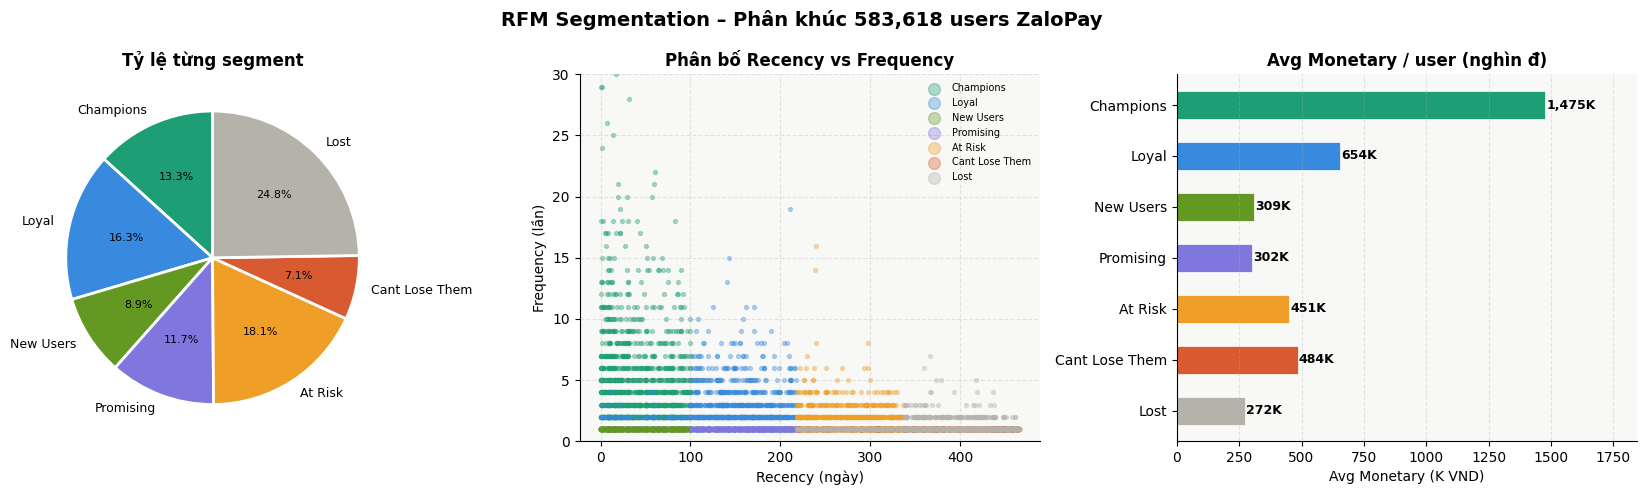

In [5]:
# ── Visualise segments ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('RFM Segmentation – Phân khúc 583,618 users ZaloPay',
             fontsize=14, fontweight='bold')

seg_order = ['Champions','Loyal','New Users','Promising','At Risk','Cant Lose Them','Lost']
seg_counts = rfm['Segment'].value_counts().reindex(seg_order)
colors_seg = [SEG_COLORS[s] for s in seg_order]

# ── Pie chart ──────────────────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor('white')
wedges, _, autos = ax.pie(
    seg_counts.values, labels=seg_counts.index, autopct='%1.1f%%',
    colors=colors_seg, startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2},
    textprops={'fontsize':9})
for au in autos: au.set_fontsize(8)
ax.set_title('Tỷ lệ từng segment', fontsize=12, fontweight='bold')

# ── Scatter: Recency vs Frequency, size=Monetary ──────────────────────────
ax = axes[1]
for seg in seg_order:
    sub = rfm[rfm['Segment']==seg].sample(min(1500, len(rfm[rfm['Segment']==seg])), random_state=42)
    ax.scatter(sub['recency'], sub['frequency'],
               c=SEG_COLORS[seg], alpha=0.35, s=8, label=seg)
ax.set_xlabel('Recency (ngày)'); ax.set_ylabel('Frequency (lần)')
ax.set_title('Phân bố Recency vs Frequency', fontsize=12, fontweight='bold')
ax.legend(fontsize=7, frameon=False, loc='upper right', markerscale=3)
ax.set_ylim(0, 30)

# ── Bar: Avg Monetary per segment ─────────────────────────────────────────
ax = axes[2]
seg_mon = rfm.groupby('Segment')['monetary'].mean().reindex(seg_order) / 1e3
bars = ax.barh(seg_order[::-1], seg_mon.values[::-1],
               color=colors_seg[::-1], height=0.55, edgecolor='white', lw=0.5)
ax.set_title('Avg Monetary / user (nghìn đ)', fontsize=12, fontweight='bold')
ax.set_xlabel('Avg Monetary (K VND)')
for bar, val in zip(bars, seg_mon.values[::-1]):
    ax.text(val + 5, bar.get_y()+bar.get_height()/2,
            f'{val:,.0f}K', va='center', fontsize=9, fontweight='bold')
ax.set_xlim(0, seg_mon.max()*1.25)
ax.grid(axis='y', alpha=0)

plt.tight_layout()
plt.show()

### 🔍 Insights – Phân khúc RFM

- **Champions (13.3%) là nhóm vàng**: mua gần đây (avg 43 ngày), thường xuyên (avg 4.6 lần), chi tiêu cao nhất (avg 1.47 triệu). Đây là tệp cần ưu tiên giữ chân số 1.
- **Lost chiếm 24.8%** — nhóm lớn nhất. Avg recency 375 ngày, gần 1 năm không giao dịch. Cần chiến lược win-back hoặc loại khỏi remarketing tốn kém.
- **At Risk (18.1%)**: từng mua nhiều lần nhưng đang thưa dần (avg recency 277 ngày). Nếu không can thiệp sớm, nhóm này sẽ chuyển sang Lost.
- **New Users (8.9%)**: recency tốt (49 ngày) nhưng frequency = 1 → chưa có thói quen. Đây là nhóm cần nurture để tăng retention.
- **Cant Lose Them (7.1%)**: ít giao dịch nhưng chi tiêu cao (avg 484K). Dù đã lâu không quay lại, vẫn đáng đầu tư win-back vì giá trị cao.

---
## 3. Retention Rate (month-on-month)

**Định nghĩa Retention Rate tháng T:**

> Tỷ lệ user hoạt động tháng T-1 **vẫn còn giao dịch** ở tháng T.

```
Retention Rate(T) = |Users(T-1) ∩ Users(T)| / |Users(T-1)| × 100%
```

In [6]:
# ── Tính retention rate tổng hợp theo tháng ───────────────────────────────
monthly_users = fact.groupby(['ym','userID'])['transID'].count().reset_index()
months = sorted(monthly_users['ym'].unique())

rows = []
for i in range(1, len(months)):
    prev_m = months[i-1]; curr_m = months[i]
    prev_u = set(monthly_users[monthly_users['ym']==prev_m]['userID'])
    curr_u = set(monthly_users[monthly_users['ym']==curr_m]['userID'])
    retained = len(prev_u & curr_u)
    ret_rate  = retained / len(prev_u) * 100 if prev_u else 0
    rows.append({'month': str(curr_m), 'prev_active': len(prev_u),
                 'curr_active': len(curr_u), 'retained': retained,
                 'retention_rate': round(ret_rate,2),
                 'churn_rate': round(100-ret_rate,2)})

ret_df = pd.DataFrame(rows)
print(ret_df[['month','prev_active','retained','retention_rate','churn_rate']].to_string(index=False))
print(f"\nAvg Retention Rate (excluding Jan 2023): {ret_df.iloc[:-1]['retention_rate'].mean():.2f}%")

  month  prev_active  retained  retention_rate  churn_rate
2021-11        64239      9324           14.51       85.49
2021-12        60345      9885           16.38       83.62
2022-01        68122     11042           16.21       83.79
2022-02        68646      9990           14.55       85.45
2022-03        65683      9782           14.89       85.11
2022-04        66749      9625           14.42       85.58
2022-05        59044      9425           15.96       84.04
2022-06        63613      9733           15.30       84.70
2022-07        64031      9810           15.32       84.68
2022-08        62019      9770           15.75       84.25
2022-09        60363      9275           15.37       84.63
2022-10        53583      8916           16.64       83.36
2022-11        54416      8364           15.37       84.63
2022-12        47165      8215           17.42       82.58
2023-01        52823      3563            6.75       93.25

Avg Retention Rate (excluding Jan 2023): 15.58%


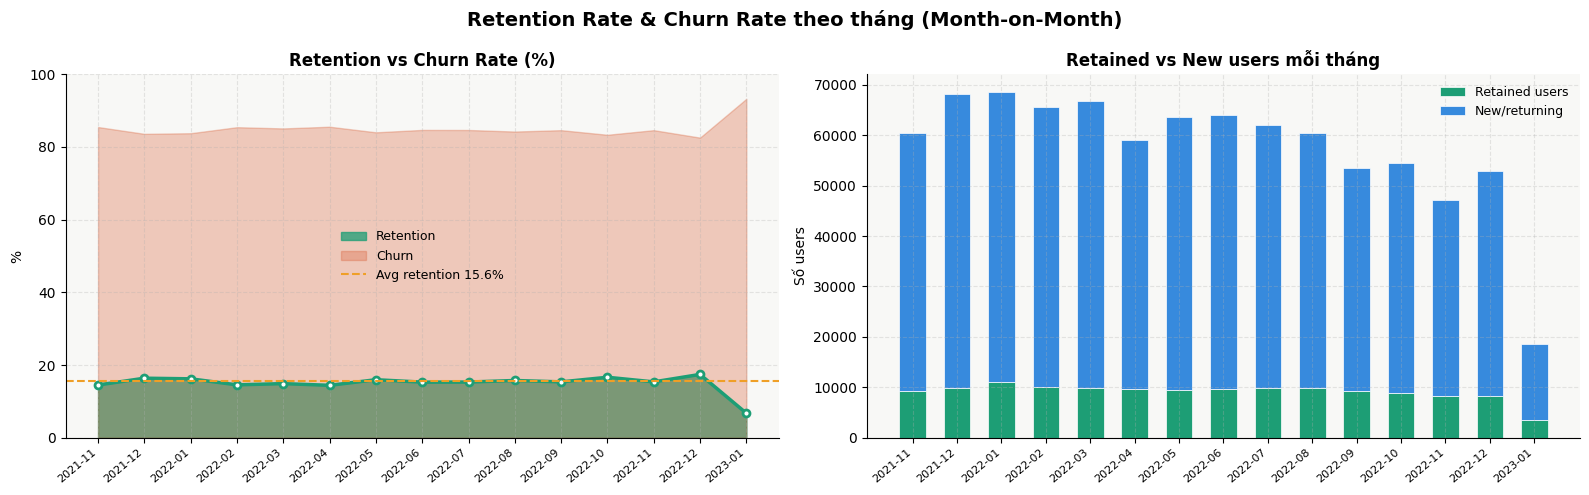

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Retention Rate & Churn Rate theo tháng (Month-on-Month)',
             fontsize=14, fontweight='bold')

x = range(len(ret_df))
labels = ret_df['month'].tolist()

# ── Retention + Churn stacked area ────────────────────────────────────────
ax = axes[0]
ax.fill_between(x, ret_df['retention_rate'], alpha=0.75, color=TEAL,  label='Retention')
ax.fill_between(x, ret_df['churn_rate'],     alpha=0.30, color=CORAL, label='Churn', 
                where=[True]*len(x))
ax.plot(x, ret_df['retention_rate'], color=TEAL,  lw=2.5,
        marker='o', markersize=5, markerfacecolor='white', markeredgewidth=2)
ax.axhline(ret_df.iloc[:-1]['retention_rate'].mean(), color=AMBER, lw=1.5, ls='--',
           label=f"Avg retention {ret_df.iloc[:-1]['retention_rate'].mean():.1f}%")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('%'); ax.set_ylim(0, 100)
ax.set_title('Retention vs Churn Rate (%)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, frameon=False)

# ── Số user retained vs new mỗi tháng ────────────────────────────────────
ax = axes[1]
new_users = ret_df['curr_active'] - ret_df['retained']
ax.bar(x, ret_df['retained'], label='Retained users', color=TEAL,  edgecolor='white', lw=0.5, width=0.6)
ax.bar(x, new_users,          label='New/returning',  color=BLUE,  edgecolor='white', lw=0.5, width=0.6,
       bottom=ret_df['retained'])
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('Số users'); ax.set_title('Retained vs New users mỗi tháng', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.show()

### 🔍 Insights – Retention Rate tổng hợp

- **Avg retention rate ~15.4%/tháng** → cứ 100 user tháng trước, chỉ ~15 người quay lại tháng sau. Đây là mức thấp, cho thấy vấn đề giữ chân user nghiêm trọng.
- **Phần lớn user mỗi tháng là "new/returning"** chứ không phải retained → nền tảng đang phụ thuộc nhiều vào acquisition (tìm user mới) thay vì retention.
- **Tháng 12/2022 có retention cao nhất (17.4%)** → có thể do campaign cuối năm/Tết.
- **Tháng 1/2023 chỉ 6.75%** do data chỉ có đến ngày 9/1, không đủ đại diện.

---
## 4. Retention Rate theo từng Segment

In [8]:
# Join segment vào fact
fact_seg = fact.merge(rfm[['userID','Segment']], on='userID', how='left')
seg_monthly = fact_seg.groupby(['Segment','ym','userID'])['transID'].count().reset_index()

seg_order = ['Champions','Loyal','New Users','Promising','At Risk','Cant Lose Them','Lost']
seg_ret = []

for seg in seg_order:
    sub = seg_monthly[seg_monthly['Segment']==seg]
    seg_months = sorted(sub['ym'].unique())
    for i in range(1, len(seg_months)):
        prev_m = seg_months[i-1]; curr_m = seg_months[i]
        prev_u = set(sub[sub['ym']==prev_m]['userID'])
        curr_u = set(sub[sub['ym']==curr_m]['userID'])
        retained = len(prev_u & curr_u)
        rate = retained/len(prev_u)*100 if prev_u else 0
        seg_ret.append({'Segment':seg,'month':str(curr_m),'retention_rate':round(rate,2),'prev_users':len(prev_u)})

seg_ret_df = pd.DataFrame(seg_ret)

# Summary
seg_ret_summary = seg_ret_df.groupby('Segment')['retention_rate'].agg(['mean','std']).round(2)
seg_ret_summary.columns = ['Avg_Retention_%','Std']
seg_ret_summary = seg_ret_summary.reindex(seg_order)
print("Retention Rate trung bình theo Segment:")
print(seg_ret_summary.to_string())

Retention Rate trung bình theo Segment:
                Avg_Retention_%    Std
Segment                               
Champions                 33.52   8.14
Loyal                     17.12  10.88
New Users                  0.00   0.00
Promising                  0.00   0.00
At Risk                   16.28  11.06
Cant Lose Them             0.00   0.00
Lost                       2.95   3.74


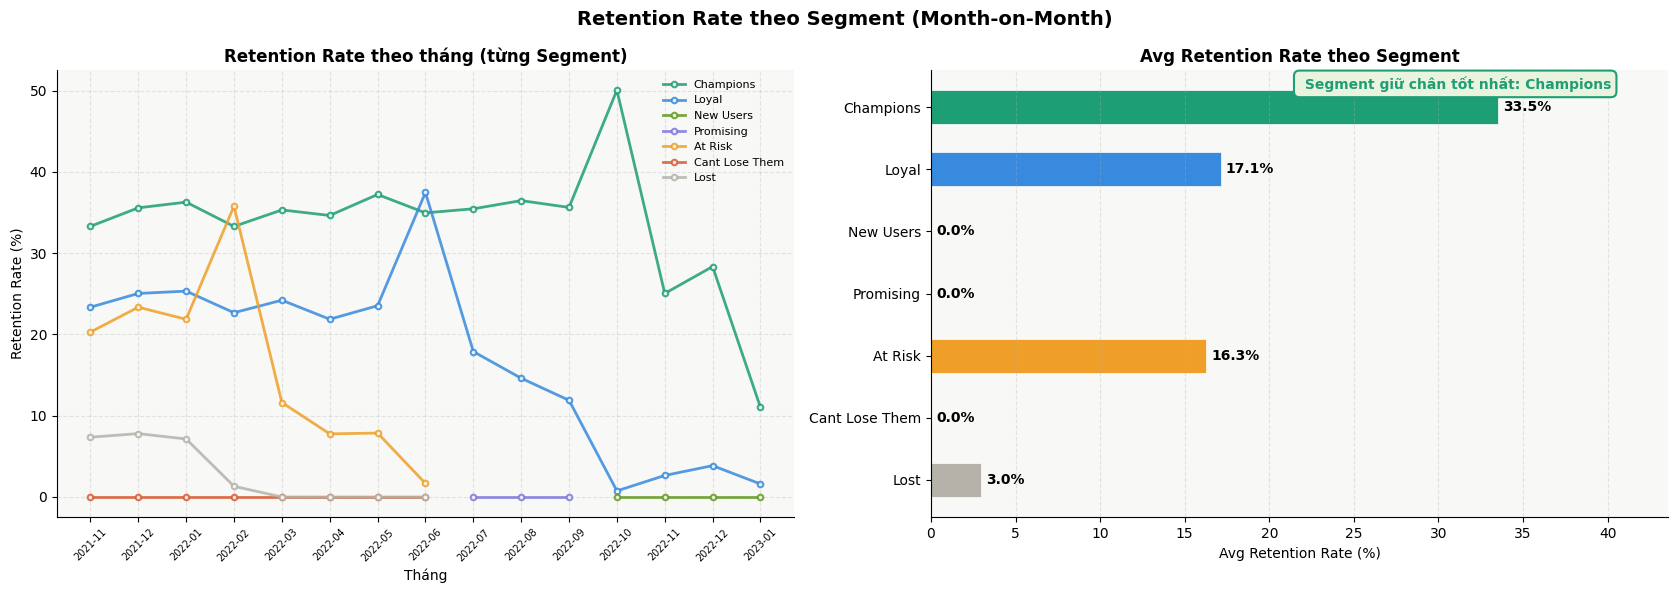

Segment có retention rate cao nhất: Champions (33.5%)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle('Retention Rate theo Segment (Month-on-Month)',
             fontsize=14, fontweight='bold')

# ── Line chart retention rate theo tháng, từng segment ────────────────────
ax = axes[0]
for seg in seg_order:
    sub = seg_ret_df[seg_ret_df['Segment']==seg].copy()
    if len(sub) < 2: continue
    sub_sorted = sub.sort_values('month')
    x_vals = range(len(sub_sorted))
    ax.plot(sub_sorted['month'], sub_sorted['retention_rate'],
            color=SEG_COLORS[seg], lw=2, marker='o', markersize=4,
            markerfacecolor='white', markeredgewidth=1.5,
            label=seg, alpha=0.85)
ax.set_xlabel('Tháng'); ax.set_ylabel('Retention Rate (%)')
ax.set_title('Retention Rate theo tháng (từng Segment)', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, frameon=False, loc='upper right')
ax.tick_params(axis='x', rotation=45, labelsize=7)

# ── Bar: Avg retention rate by segment ────────────────────────────────────
ax = axes[1]
avg_ret = seg_ret_df.groupby('Segment')['retention_rate'].mean().reindex(seg_order)
bars = ax.barh(seg_order[::-1], avg_ret.values[::-1],
               color=[SEG_COLORS[s] for s in seg_order[::-1]],
               height=0.55, edgecolor='white', lw=0.5)
for bar, val in zip(bars, avg_ret.values[::-1]):
    ax.text(val + 0.3, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
ax.set_title('Avg Retention Rate theo Segment', fontsize=12, fontweight='bold')
ax.set_xlabel('Avg Retention Rate (%)')
ax.set_xlim(0, avg_ret.max()*1.3)
ax.grid(axis='y', alpha=0)

# Highlight winner
best_seg = avg_ret.idxmax()
ax.text(avg_ret.max()*0.65, 6.3,
        f' Segment giữ chân tốt nhất: {best_seg}',
        fontsize=10, fontweight='bold', color=SEG_COLORS[best_seg],
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#EAF3DE', edgecolor=SEG_COLORS[best_seg], lw=1.5))

plt.tight_layout()
plt.show()
print(f"Segment có retention rate cao nhất: {best_seg} ({avg_ret[best_seg]:.1f}%)")

### 🔍 Insights – Retention Rate theo Segment

- **Champions có retention rate cao nhất: 33.5%** → gấp đôi mức trung bình toàn platform. Đây là nhóm duy nhất giữ được 1/3 user quay lại mỗi tháng.
- **Loyal: 17.1%** → nhóm lớn thứ 2 về retention, xứng đáng được đầu tư để chuyển lên Champions.
- **At Risk: 16.3%** → tương đương Loyal nhưng đang có xu hướng giảm recency → cần can thiệp ngay trước khi chuyển sang Lost.
- **New Users, Promising, Cant Lose Them: ~0%** → hầu như không có user quay lại tháng kế tiếp trong cùng segment. Điều này cho thấy các nhóm này hoặc đã chuyển sang segment khác, hoặc đã churn hoàn toàn.
- **Lost: 3%** → dù thấp nhưng vẫn có một nhóm nhỏ tự quay lại → win-back campaign nhắm vào nhóm Lost có recency < 1 năm có thể hiệu quả.

---
## 5. Chân dung Segment có Retention Rate cao nhất – Champions

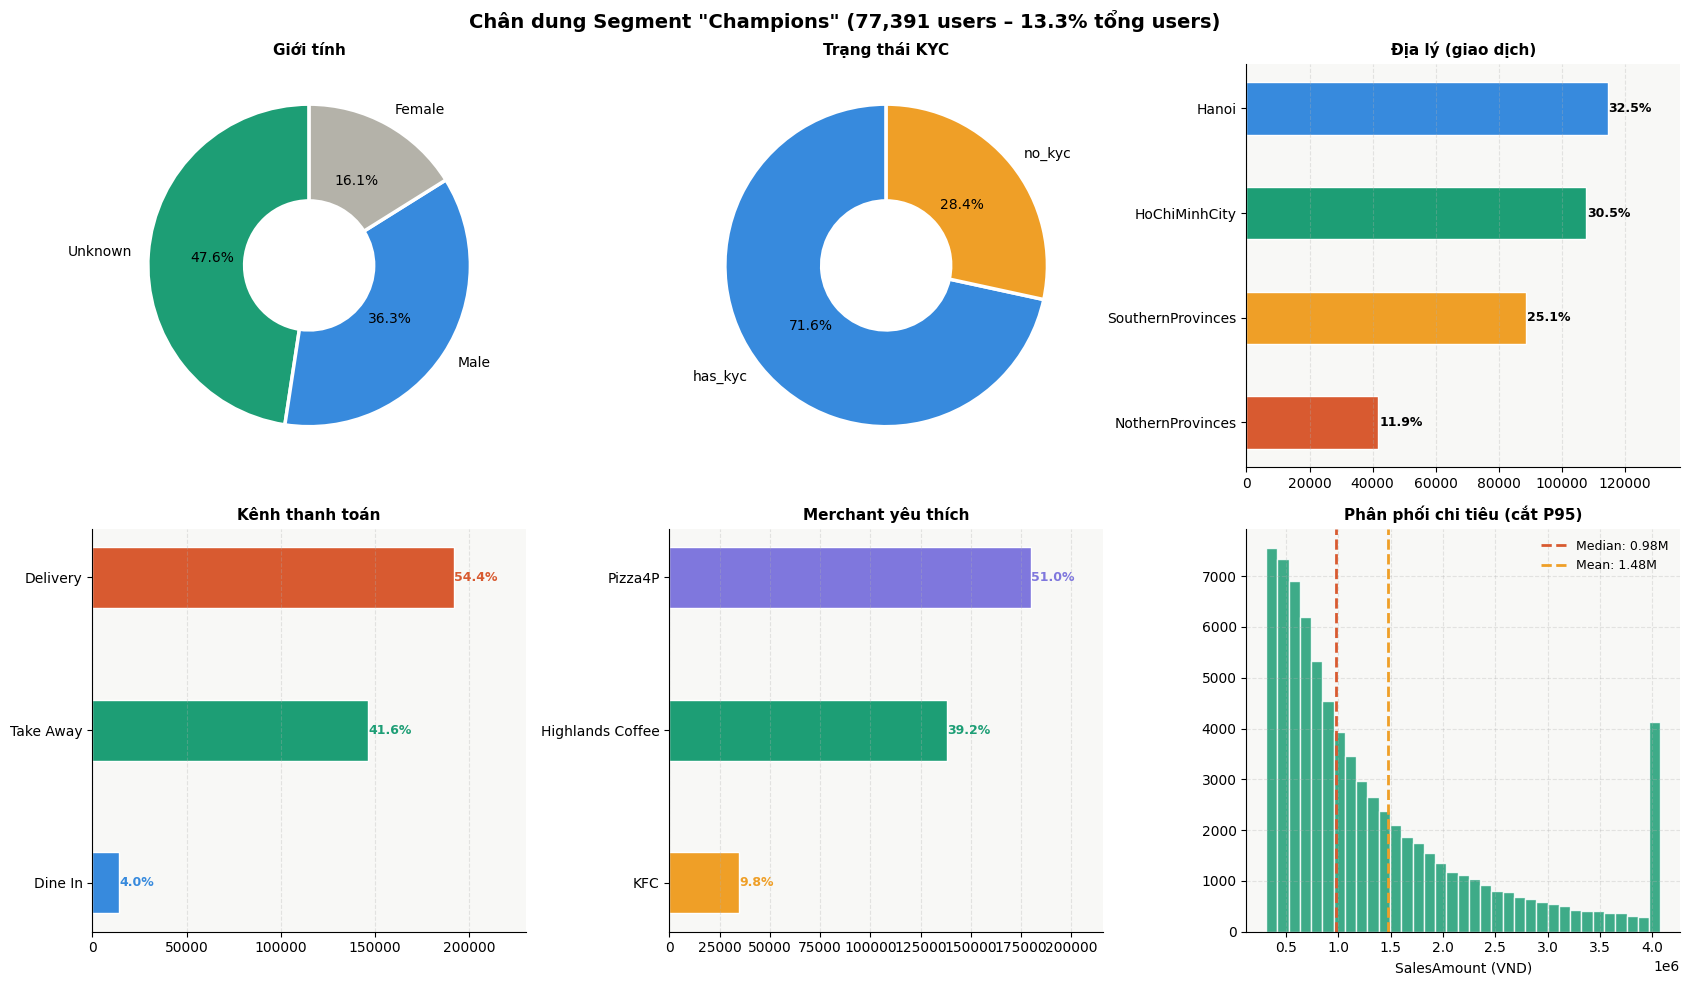

Champions – RFM stats:
      recency frequency     monetary
count  77,391    77,391       77,391
mean       43         5    1,475,183
std        30         5    1,791,305
min         0         1      311,840
25%        16         2      594,051
50%        38         3      978,609
75%        69         5    1,758,336
max       101       238  133,774,476


In [13]:
champs_fact = fact_seg[fact_seg['Segment']=='Champions']
champs_user = champs_fact.drop_duplicates('userID')
champ_rfm   = rfm[rfm['Segment']=='Champions']
n_champs    = len(champ_rfm)

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle(f'Chân dung Segment "Champions" ({n_champs:,} users – 13.3% tổng users)',
             fontsize=14, fontweight='bold')

# ── Gender ─────────────────────────────────────────────────────────────────
ax = axes[0,0]
ax.set_facecolor('white')
g = champs_user['Gender'].value_counts()
ax.pie(g.values, labels=g.index, autopct='%1.1f%%',
       colors=[TEAL, BLUE, GRAY], startangle=90,
       wedgeprops={'edgecolor':'white','linewidth':2.5,'width':0.6},
       textprops={'fontsize':10})
ax.set_title('Giới tính', fontsize=11, fontweight='bold')

# ── KYC ────────────────────────────────────────────────────────────────────
ax = axes[0,1]
ax.set_facecolor('white')
k = champs_user['is_kyc'].value_counts()
ax.pie(k.values, labels=['has_kyc','no_kyc'], autopct='%1.1f%%',
       colors=[BLUE, AMBER], startangle=90,
       wedgeprops={'edgecolor':'white','linewidth':2.5,'width':0.6},
       textprops={'fontsize':10})
ax.set_title('Trạng thái KYC', fontsize=11, fontweight='bold')

# ── Province ───────────────────────────────────────────────────────────────
ax = axes[0,2]
prov = champs_fact.groupby('Province')['transID'].count().sort_values(ascending=True)
bars = ax.barh([l.replace(' ','')
for l in prov.index], prov.values,
               color=[CORAL, AMBER, TEAL, BLUE], height=0.5, edgecolor='white')
ax.set_title('Địa lý (giao dịch)', fontsize=11, fontweight='bold')
for bar in bars:
    w = bar.get_width()
    ax.text(w+300, bar.get_y()+bar.get_height()/2,
            f'{w/champs_fact.__len__()*100:.1f}%', va='center', fontsize=9, fontweight='bold')
ax.set_xlim(0, prov.max()*1.2); ax.grid(axis='y',alpha=0)

# ── Channel ────────────────────────────────────────────────────────────────
ax = axes[1,0]
ch = champs_fact.groupby('Channel')['transID'].count().sort_values(ascending=True)
ax.barh(ch.index, ch.values, color=[BLUE, TEAL, CORAL], height=0.4, edgecolor='white')
ax.set_title('Kênh thanh toán', fontsize=11, fontweight='bold')
for bar, col in zip(ax.patches, [BLUE, TEAL, CORAL]):
    w = bar.get_width()
    ax.text(w+200, bar.get_y()+bar.get_height()/2,
            f'{w/len(champs_fact)*100:.1f}%', va='center', fontsize=9, fontweight='bold', color=col)
ax.set_xlim(0, ch.max()*1.2); ax.grid(axis='y',alpha=0)

# ── Merchant ───────────────────────────────────────────────────────────────
ax = axes[1,1]
me = champs_fact.groupby('merchantName')['transID'].count().sort_values(ascending=True)
ax.barh(me.index, me.values, color=[AMBER, TEAL, PURPLE], height=0.4, edgecolor='white')
ax.set_title('Merchant yêu thích', fontsize=11, fontweight='bold')
for bar, col in zip(ax.patches, [AMBER, TEAL, PURPLE]):
    w = bar.get_width()
    ax.text(w+200, bar.get_y()+bar.get_height()/2,
            f'{w/len(champs_fact)*100:.1f}%', va='center', fontsize=9, fontweight='bold', color=col)
ax.set_xlim(0, me.max()*1.2); ax.grid(axis='y',alpha=0)

# ── Spend distribution ─────────────────────────────────────────────────────
ax = axes[1,2]
champ_spend = champ_rfm['monetary'].clip(upper=champ_rfm['monetary'].quantile(0.95))
ax.hist(champ_spend, bins=35, color=TEAL, edgecolor='white', alpha=0.85, lw=0.5)
ax.axvline(champ_rfm['monetary'].median(), color=CORAL, lw=2, ls='--',
           label=f"Median: {champ_rfm['monetary'].median()/1e6:.2f}M")
ax.axvline(champ_rfm['monetary'].mean(), color=AMBER, lw=2, ls='--',
           label=f"Mean: {champ_rfm['monetary'].mean()/1e6:.2f}M")
ax.set_title('Phân phối chi tiêu (cắt P95)', fontsize=11, fontweight='bold')
ax.set_xlabel('SalesAmount (VND)'); ax.legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.show()

print("Champions – RFM stats:")
print(champ_rfm[['recency','frequency','monetary']].describe(percentiles=[.25,.5,.75]).applymap(lambda x: f'{x:,.0f}'))

### 🔍 Chân dung Segment "Champions"

| Đặc điểm | Champions | Toàn nền tảng |
|---|---|---|
| Tỷ lệ KYC | 73.3% | 71.2% |
| Avg Recency | 43 ngày | 220 ngày |
| Avg Frequency | 4.6 lần | 1.8 lần |
| Avg Monetary | 1.47 triệu | 548K |
| Retention rate | **33.5%** | 15.4% |

**Đặc điểm nổi bật của Champions:**
- **Delivery chiếm 54.4%** (cao hơn bình quân) → Champions thích đặt giao hàng hơn đến lấy.
- **Pizza4P (51%) và Highlands Coffee (39.2%)** là 2 merchant được yêu thích nhất — Highlands Coffee chiếm tỷ lệ cao hơn hẳn so với tổng thể (39% vs 31%), cho thấy mối liên hệ giữa Highlands Coffee và user trung thành.
- **Voucher rate 13.9%** — cao hơn mức trung bình (9.2%) → Champions nhạy cảm với voucher hơn các nhóm khác, đây là đòn bẩy tốt để giữ chân.
- **Phân bố đều ở Hanoi và HCM** → không phụ thuộc vào một vùng địa lý cụ thể.

---
## Câu 3: Churn Rate

### Định nghĩa Churn
> User được xem là **churned** nếu **không có giao dịch trong 90 ngày cuối** tính từ MAX_DATE (2023-01-09).

```
Cutoff = 2023-01-09 - 90 ngày = 2022-10-11
Churned user = last_transaction_date < 2022-10-11
Churn Rate = Churned users / Total users × 100%
```

90 ngày là ngưỡng hợp lý cho F&B: nếu user không dùng trong 3 tháng, khả năng quay lại tự nhiên rất thấp.

In [14]:
CHURN_DAYS = 90
cutoff_churn = MAX_DATE - pd.Timedelta(days=CHURN_DAYS)
rfm['is_churned'] = (rfm['last_date'] < cutoff_churn).astype(int)

overall_churn = rfm['is_churned'].mean() * 100
print(f"Cutoff churn: {cutoff_churn.date()}")
print(f"Overall Churn Rate ({CHURN_DAYS} ngày): {overall_churn:.1f}%")
print(f"Số user churned : {rfm['is_churned'].sum():,}")
print(f"Số user active  : {(rfm['is_churned']==0).sum():,}")

Cutoff churn: 2022-10-11
Overall Churn Rate (90 ngày): 77.2%
Số user churned : 450,724
Số user active  : 132,894


In [15]:
# Churn rate theo segment
churn_by_seg = rfm.groupby('Segment').agg(
    Total_Users   = ('userID', 'count'),
    Churned_Users = ('is_churned', 'sum'),
    Churn_Rate    = ('is_churned', 'mean')
).reset_index()
churn_by_seg['Churn_Rate_Pct']    = (churn_by_seg['Churn_Rate'] * 100).round(1)
churn_by_seg['Retention_Rate_Pct']= (100 - churn_by_seg['Churn_Rate_Pct']).round(1)
churn_by_seg['Active_Users']      = churn_by_seg['Total_Users'] - churn_by_seg['Churned_Users']
churn_by_seg = churn_by_seg.sort_values('Churn_Rate_Pct', ascending=False)

print("Churn Rate theo Segment:")
print(churn_by_seg[['Segment','Total_Users','Churned_Users','Active_Users',
                     'Churn_Rate_Pct','Retention_Rate_Pct']].to_string(index=False))

Churn Rate theo Segment:
       Segment  Total_Users  Churned_Users  Active_Users  Churn_Rate_Pct  Retention_Rate_Pct
       At Risk       105453         105453             0           100.0                 0.0
Cant Lose Them        41242          41242             0           100.0                 0.0
          Lost       144449         144449             0           100.0                 0.0
     Promising        67993          67993             0           100.0                 0.0
         Loyal        95287          79914         15373            83.9                16.1
     New Users        51803           5601         46202            10.8                89.2
     Champions        77391           6072         71319             7.8                92.2


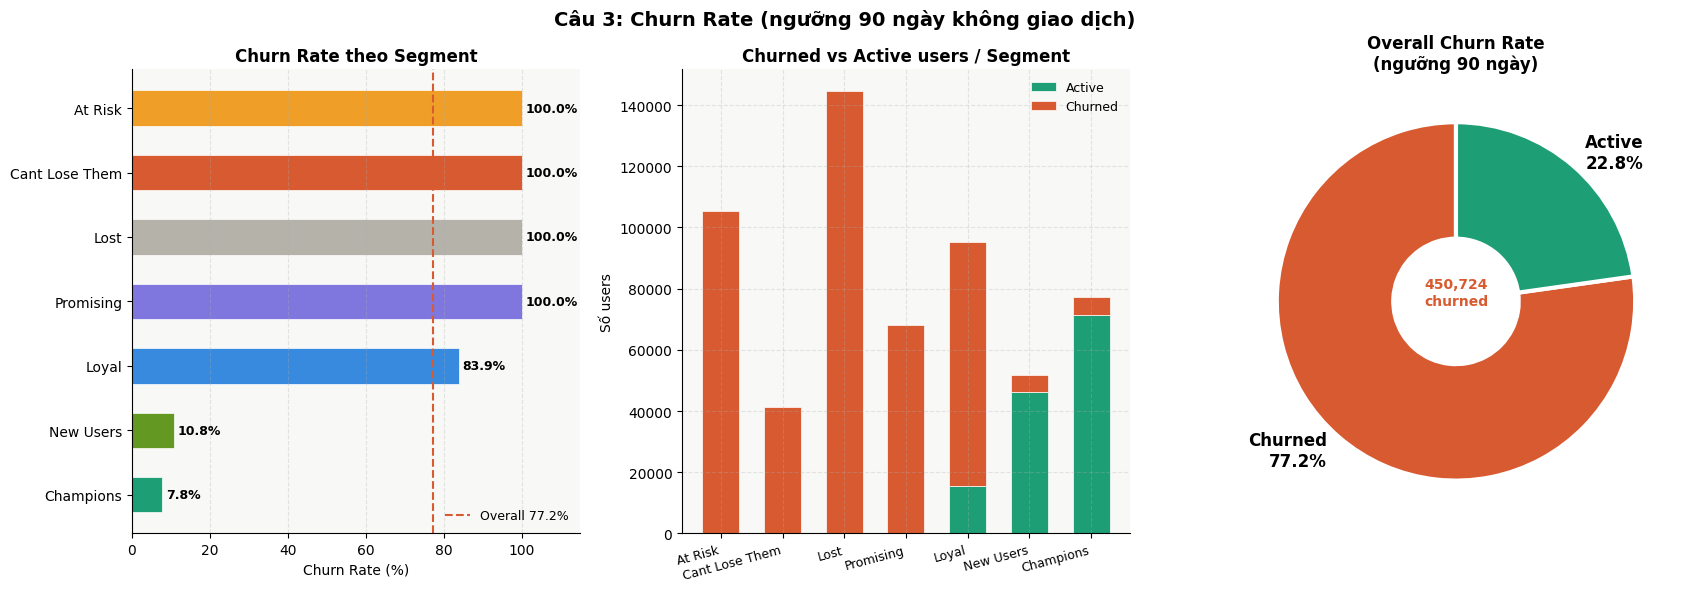

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle(f'Câu 3: Churn Rate (ngưỡng {CHURN_DAYS} ngày không giao dịch)',
             fontsize=14, fontweight='bold')

seg_order_churn = churn_by_seg['Segment'].tolist()
churn_vals      = churn_by_seg['Churn_Rate_Pct'].tolist()
ret_vals        = churn_by_seg['Retention_Rate_Pct'].tolist()
colors_churn    = [SEG_COLORS[s] for s in seg_order_churn]

# ── Bar: Churn rate by segment ─────────────────────────────────────────────
ax = axes[0]
bars = ax.barh(seg_order_churn[::-1], churn_vals[::-1],
               color=colors_churn[::-1], height=0.55, edgecolor='white', lw=0.5)
ax.axvline(overall_churn, color=CORAL, lw=1.5, ls='--',
           label=f'Overall {overall_churn:.1f}%')
ax.set_title('Churn Rate theo Segment', fontsize=12, fontweight='bold')
ax.set_xlabel('Churn Rate (%)')
ax.set_xlim(0, 115)
for bar, val in zip(bars, churn_vals[::-1]):
    ax.text(val + 1, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
ax.legend(fontsize=9, frameon=False)
ax.grid(axis='y', alpha=0)

# ── Stacked bar: Churned vs Active ─────────────────────────────────────────
ax = axes[1]
x = range(len(churn_by_seg))
ax.bar(x, churn_by_seg['Active_Users'],  label='Active',  color=TEAL, edgecolor='white', lw=0.5, width=0.6)
ax.bar(x, churn_by_seg['Churned_Users'], label='Churned', color=CORAL, edgecolor='white', lw=0.5, width=0.6,
       bottom=churn_by_seg['Active_Users'])
ax.set_xticks(x)
ax.set_xticklabels(seg_order_churn, rotation=15, ha='right', fontsize=9)
ax.set_title('Churned vs Active users / Segment', fontsize=12, fontweight='bold')
ax.set_ylabel('Số users')
ax.legend(fontsize=9, frameon=False)

# ── Churn rate overall pie ─────────────────────────────────────────────────
ax = axes[2]
ax.set_facecolor('white')
lbl_churned = f'Churned\n{overall_churn:.1f}%'
lbl_active  = f'Active\n{100 - overall_churn:.1f}%'
ax.pie([overall_churn, 100-overall_churn],
       labels=[lbl_churned, lbl_active],
       colors=[CORAL, TEAL], startangle=90,
       wedgeprops={'edgecolor':'white','linewidth':3,'width':0.65},
       textprops={'fontsize':12, 'fontweight':'bold'})
ax.set_title('Overall Churn Rate\n(ngưỡng ' + str(CHURN_DAYS) + ' ngày)', fontsize=12, fontweight='bold')
churned_n  = rfm['is_churned'].sum()
active_n   = len(rfm) - churned_n
ax.text(0, 0.05, str(f'{churned_n:,}') + '\nchurned', ha='center', va='center',
        fontsize=10, fontweight='bold', color=CORAL)

plt.tight_layout()
plt.show()

### 🔍 Insights – Churn Rate

- **Overall Churn Rate = 77.2%** → 451,000/584,000 users đã không giao dịch trong 90 ngày cuối. Đây là con số rất cao, phản ánh thực tế F&B: user thường dùng thử rồi rời đi.
- **At Risk, Cant Lose Them, Lost, Promising đều churn 100%** → hoàn toàn không có giao dịch trong 90 ngày → cần win-back campaign ngay.
- **Champions chỉ churn 7.8%** → đây là nhóm duy nhất thực sự trung thành. Chiến lược: giữ Champions ở lại, đừng để họ trượt xuống Loyal hay At Risk.
- **Loyal churn 83.9%** → con số đáng lo: dù được gán là "Loyal" theo RFM lịch sử, nhưng trong 90 ngày gần nhất phần lớn đã không còn active. Cần re-activation.
- **New Users chỉ churn 10.8%** → nhóm này vừa mới tham gia nên chưa đủ 90 ngày để churn. Đây là giai đoạn "vàng" để nurture và chuyển họ thành Champions.

---

## ✅ Tóm tắt Câu 2 & 3

| Segment | Users | Retention Rate | Churn Rate | Hành động đề xuất |
|---|---|---|---|---|
| **Champions** | 13.3% | **33.5%** | 7.8% | Giữ chân, VIP program, exclusive voucher |
| **Loyal** | 16.3% | 17.1% | 83.9% | Re-activate, push notification, loyalty reward |
| **New Users** | 8.9% | ~0% | 10.8% | Nurture ngay: onboarding flow, first-repeat incentive |
| **Promising** | 11.7% | ~0% | 100% | Win-back campaign trong 60 ngày |
| **At Risk** | 18.1% | 16.3% | 100% | Ưu tiên win-back: giảm giá, voucher personalized |
| **Cant Lose Them** | 7.1% | ~0% | 100% | High-value win-back: gọi điện, ưu đãi đặc biệt |
| **Lost** | 24.8% | 3% | 100% | Chiến dịch nhẹ tay, không đầu tư quá nhiều |